<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/ids_pcap_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install torch-geometric -q

In [7]:
pip install pandas numpy scikit-learn matplotlib seaborn networkx tqdm

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.3 MB 11.3 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.3 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 20.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 28.8 MB/s  0:00:00

   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ --------------------------------- 1/6 [fonttools]
   ------ ---------

In [8]:
import os

import pandas as pd
import numpy as np

import torch

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data

In [ ]:
DATASET_DIR = "/Users/balji/OneDrive/GNN_IDS/Balanced_6Class_400K"

files = {
    "BENIGN.csv":0,
    "DDoS.csv":1,
    "DoS.csv":1,
    "Mirai.csv":1,
    "Recon.csv":1,
    "Spoofing.csv":1
}

dfs = []

for file,label in files.items():

    path = os.path.join(DATASET_DIR,file)

    df = pd.read_csv(path)

    df["label"] = label

    dfs.append(df)

data = pd.concat(
    dfs,
    ignore_index=True
)

print(data.shape)

(400000, 87)


In [ ]:
data = data.sort_values(
    "bidirectional_first_seen_ms"
).reset_index(drop=True)

data["flow_id"] = np.arange(len(data))

print(data.shape)

(400000, 88)


In [ ]:
DROP_COLS = [

    "id",
    "expiration_id",

    "src_ip",
    "dst_ip",

    "src_mac",
    "dst_mac",

    "src_oui",
    "dst_oui",

    "requested_server_name",

    "client_fingerprint",
    "server_fingerprint",

    "user_agent",
    "content_type",

    "application_name",
    "application_category_name",

    "flow_id",
    "label",

    "bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",

    "src2dst_first_seen_ms",
    "src2dst_last_seen_ms",

    "dst2src_first_seen_ms",
    "dst2src_last_seen_ms",

    "application_confidence",
    "application_is_guessed"

]

feature_cols = [

    c
    for c in data.columns
    if c not in DROP_COLS
]

print("Features:",len(feature_cols))

Features: 63


In [ ]:
for col in feature_cols:

    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

data[feature_cols] = (
    data[feature_cols]
    .fillna(0)
)

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(
    data[feature_cols]
)

print(X.shape)

(400000, 63)


In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(
    data[feature_cols]
)

print(X.shape)

(400000, 63)


In [ ]:
all_hosts = pd.concat(
    [
        data["src_ip"],
        data["dst_ip"]
    ]
).unique()

host_to_id = {

    host : idx + len(data)

    for idx,host
    in enumerate(all_hosts)
}

num_flow_nodes = len(data)

num_host_nodes = len(all_hosts)

print("Flow Nodes:",num_flow_nodes)
print("Host Nodes:",num_host_nodes)

Flow Nodes: 400000
Host Nodes: 4572


In [ ]:
edges = []

for flow_id,row in data.iterrows():

    src_host = host_to_id[
        row["src_ip"]
    ]

    dst_host = host_to_id[
        row["dst_ip"]
    ]

    edges.append(
        [flow_id,src_host]
    )

    edges.append(
        [src_host,flow_id]
    )

    edges.append(
        [flow_id,dst_host]
    )

    edges.append(
        [dst_host,flow_id]
    )

print("Host-flow edges built")

Host-flow edges built


In [ ]:
print(graph.num_edges)

1600000


In [ ]:
src_groups = data.groupby(
    "src_ip"
)["flow_id"].apply(list)

print(
    "Groups:",
    len(src_groups)
)

Groups: 1303


In [ ]:
edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(edge_index.shape)

torch.Size([2, 1600000])


In [ ]:
flow_features = torch.tensor(
    X,
    dtype=torch.float
)

In [ ]:
host_features = torch.zeros(

    (
        num_host_nodes,
        flow_features.shape[1]
    ),

    dtype=torch.float
)

host_counts = np.zeros(
    num_host_nodes
)

for flow_id,row in data.iterrows():

    src_idx = (
        host_to_id[
            row["src_ip"]
        ]
        -
        num_flow_nodes
    )

    dst_idx = (
        host_to_id[
            row["dst_ip"]
        ]
        -
        num_flow_nodes
    )

    host_features[src_idx] += flow_features[flow_id]
    host_features[dst_idx] += flow_features[flow_id]

    host_counts[src_idx] += 1
    host_counts[dst_idx] += 1

for i in range(num_host_nodes):

    if host_counts[i] > 0:

        host_features[i] /= (
            host_counts[i]
        )

In [ ]:
x = torch.cat(
    [
        flow_features,
        host_features
    ],
    dim=0
)

print(x.shape)

torch.Size([404572, 63])


In [ ]:
flow_labels = torch.tensor(
    data["label"].values,
    dtype=torch.long
)

host_labels = torch.full(
    (
        num_host_nodes,
    ),
    -1,
    dtype=torch.long
)

y = torch.cat(
    [
        flow_labels,
        host_labels
    ]
)

print(y.shape)

torch.Size([404572])


In [ ]:
idx = np.arange(
    num_flow_nodes
)

train_idx,test_idx = train_test_split(

    idx,

    test_size=0.2,

    random_state=42,

    stratify=flow_labels.numpy()
)

In [ ]:
total_nodes = (
    num_flow_nodes
    +
    num_host_nodes
)

train_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

test_mask = torch.zeros(
    total_nodes,
    dtype=torch.bool
)

train_mask[
    train_idx
] = True

test_mask[
    test_idx
] = True

In [ ]:
graph = Data(

    x=x,

    edge_index=edge_index,

    y=y,

    train_mask=train_mask,

    test_mask=test_mask
)

print(graph)

print(
    "Nodes:",
    graph.num_nodes
)

print(
    "Edges:",
    graph.num_edges
)

Data(x=[404572, 63], edge_index=[2, 1600000], y=[404572], train_mask=[404572], test_mask=[404572])
Nodes: 404572
Edges: 1600000


In [ ]:
import torch
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        in_channels,
        hidden_channels,
        num_classes
    ):

        super().__init__()

        self.conv1 = SAGEConv(
            in_channels,
            hidden_channels
        )

        self.conv2 = SAGEConv(
            hidden_channels,
            hidden_channels
        )

        self.conv3 = SAGEConv(
            hidden_channels,
            hidden_channels // 2
        )

        self.bn1 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn2 = torch.nn.BatchNorm1d(
            hidden_channels
        )

        self.bn3 = torch.nn.BatchNorm1d(
            hidden_channels // 2
        )

        self.classifier = torch.nn.Linear(
            hidden_channels // 2,
            num_classes
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x = self.conv1(
            x,
            edge_index
        )

        x = self.bn1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv2(
            x,
            edge_index
        )

        x = self.bn2(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.4,
            training=self.training
        )

        x = self.conv3(
            x,
            edge_index
        )

        x = self.bn3(x)

        x = F.relu(x)

        x = self.classifier(x)

        return x

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
model = GraphSAGE(
    in_channels=graph.num_node_features,
    hidden_channels=256,
    num_classes=2
)

model = model.to(device)

graph = graph.to(device)

print(model)

GraphSAGE(
  (conv1): SAGEConv(63, 256, aggr=mean)
  (conv2): SAGEConv(256, 256, aggr=mean)
  (conv3): SAGEConv(256, 128, aggr=mean)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)


In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.002,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5
)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
def train():

    model.train()

    optimizer.zero_grad()

    out = model(
        graph.x,
        graph.edge_index
    )

    loss = criterion(
        out[graph.train_mask],
        graph.y[graph.train_mask]
    )

    loss.backward()

    optimizer.step()

    return loss.item()

In [ ]:
@torch.no_grad()

def evaluate(mask):

    model.eval()

    out = model(
        graph.x,
        graph.edge_index
    )

    pred = out.argmax(
        dim=1
    )

    correct = (
        pred[mask]
        ==
        graph.y[mask]
    ).sum()

    acc = (
        correct.item()
        /
        mask.sum().item()
    )

    return acc

In [ ]:
for epoch in range(
    1,
    51
):

    loss = train()

    train_acc = evaluate(
        graph.train_mask
    )

    test_acc = evaluate(
        graph.test_mask
    )

    scheduler.step()

    print(
        f"Epoch {epoch:02d}"
        f" | Loss {loss:.4f}"
        f" | Train {train_acc:.4f}"
        f" | Test {test_acc:.4f}"
    )

Epoch 01 | Loss 0.1599 | Train 0.9452 | Test 0.9464
Epoch 02 | Loss 0.1625 | Train 0.9452 | Test 0.9464
Epoch 03 | Loss 0.1782 | Train 0.9447 | Test 0.9461
Epoch 04 | Loss 0.1829 | Train 0.9448 | Test 0.9461
Epoch 05 | Loss 0.1586 | Train 0.9448 | Test 0.9463
Epoch 06 | Loss 0.1718 | Train 0.9447 | Test 0.9462
Epoch 07 | Loss 0.1579 | Train 0.9445 | Test 0.9460
Epoch 08 | Loss 0.1679 | Train 0.9455 | Test 0.9467
Epoch 09 | Loss 0.1543 | Train 0.9456 | Test 0.9467
Epoch 10 | Loss 0.1655 | Train 0.9456 | Test 0.9468
Epoch 11 | Loss 0.1558 | Train 0.9454 | Test 0.9466
Epoch 12 | Loss 0.1653 | Train 0.9456 | Test 0.9468
Epoch 13 | Loss 0.1589 | Train 0.9456 | Test 0.9468
Epoch 14 | Loss 0.1881 | Train 0.9451 | Test 0.9464
Epoch 15 | Loss 0.1580 | Train 0.9451 | Test 0.9463
Epoch 16 | Loss 0.1535 | Train 0.9456 | Test 0.9467
Epoch 17 | Loss 0.1600 | Train 0.9456 | Test 0.9467
Epoch 18 | Loss 0.1573 | Train 0.9453 | Test 0.9465
Epoch 19 | Loss 0.1588 | Train 0.9455 | Test 0.9466
Epoch 20 | L

In [ ]:
model.eval()

with torch.no_grad():

    out = model(
        graph.x,
        graph.edge_index
    )

    pred = out.argmax(
        dim=1
    )

In [ ]:
from sklearn.metrics import (
    classification_report
)

print(

    classification_report(

        graph.y[
            graph.test_mask
        ].cpu(),

        pred[
            graph.test_mask
        ].cpu()
    )
)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     40000
           1       0.98      0.91      0.94     40000

    accuracy                           0.95     80000
   macro avg       0.95      0.95      0.95     80000
weighted avg       0.95      0.95      0.95     80000



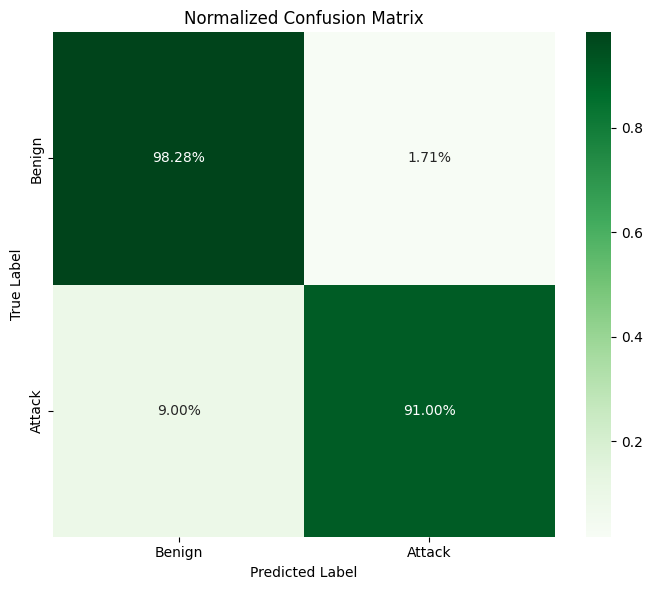

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = graph.y[graph.test_mask].cpu().numpy()

# Predicted labels
y_pred = pred[graph.test_mask].cpu().numpy()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize row-wise
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2%",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()